# Complete code for replicating results

In [239]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import torch

In [122]:
llama_df = pd.read_csv("pcaps/llama.csv", encoding='latin-1')
gemini_df = pd.read_csv("pcaps/gemini.csv", encoding='latin-1')
grok_df = pd.read_csv("pcaps/grok.csv", encoding='latin-1')

with open('src/llama.json', 'r') as f: llama_labels = json.load(f)
with open('src/gemini.json', 'r') as f: gemini_labels = json.load(f)
with open('src/grok.json', 'r') as f: grok_labels = json.load(f)

## basic utility functions

In [123]:
def extract_ip_addresses_from_dns_info(info_str):
    words = info_str.split(' ')
    ips = []
    
    for w in words:
        if len(w.split('.')) == 4:
            ips.append(w)
    return ips

In [124]:
def get_open_website_ips(df, website_name):
    dns_packets = df[df["Protocol"] == "DNS"].iterrows()
    open_router_ips = []
    
    for row in dns_packets:
        info_str = row[1]["Info"]
        if ("Standard query response" in info_str) and (website_name in info_str):
            new_open_router_ips = extract_ip_addresses_from_dns_info(info_str)
            open_router_ips.extend(new_open_router_ips)          
    return list(set(open_router_ips))

## visualize/investigate data

In [125]:
def plot_first_n_api_calls(model_df, n,title=""):

    assert n > 0
    dns_artifcat_times = []

    for i, row in model_df.iterrows():
        if len(dns_artifcat_times) >= n:
            break
        
        info_str = row['Info']
        if ("Standard query response" in info_str) and ('zephaniahdev.com' in info_str):
            dns_artifcat_times.append(row['Time'])

    open_router_ips = get_open_website_ips(model_df, "openrouter.ai")
    first_api_calls_df = model_df[model_df['Time'] < dns_artifcat_times[-1]]
    only_open_router = first_api_calls_df[first_api_calls_df['Source'].isin(open_router_ips) | first_api_calls_df['Destination'].isin(open_router_ips) ]

    # claude helped with some basic plotting here
    # https://claude.ai/share/c4f19cf7-0add-4b23-b071-ee2b05c732aa
    plt.figure(figsize=(13, 6))
    plt.scatter(only_open_router['Time'], only_open_router['Length'])
    for t in dns_artifcat_times:
        plt.axvline(x=t, color='orange', linestyle='-')

    plt.title(title)
    plt.xlabel("time in seconds")
    plt.ylabel("length of packet")
    plt.show()

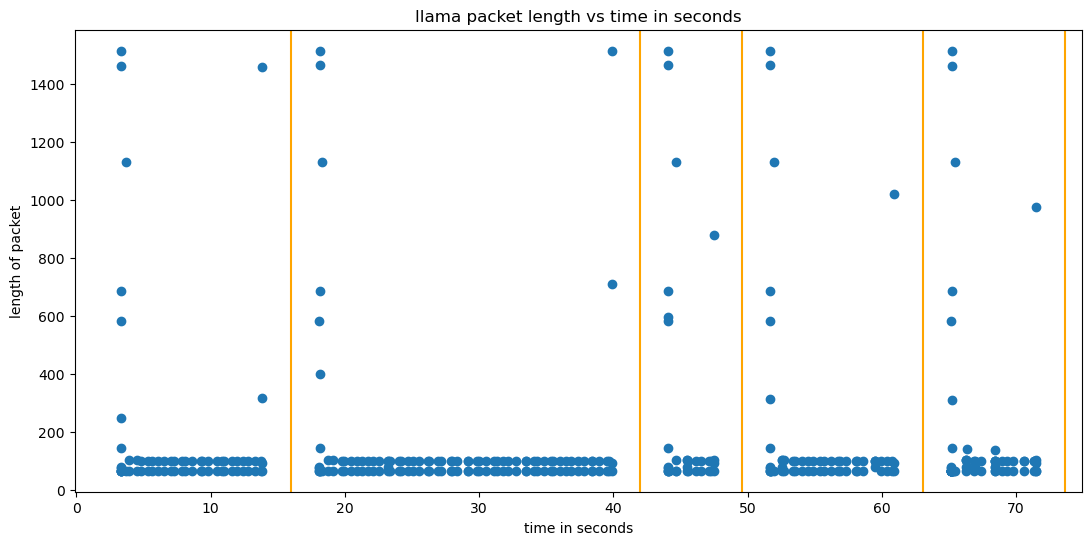

In [126]:
# llama
plot_first_n_api_calls(llama_df, 5, "llama packet length vs time in seconds")

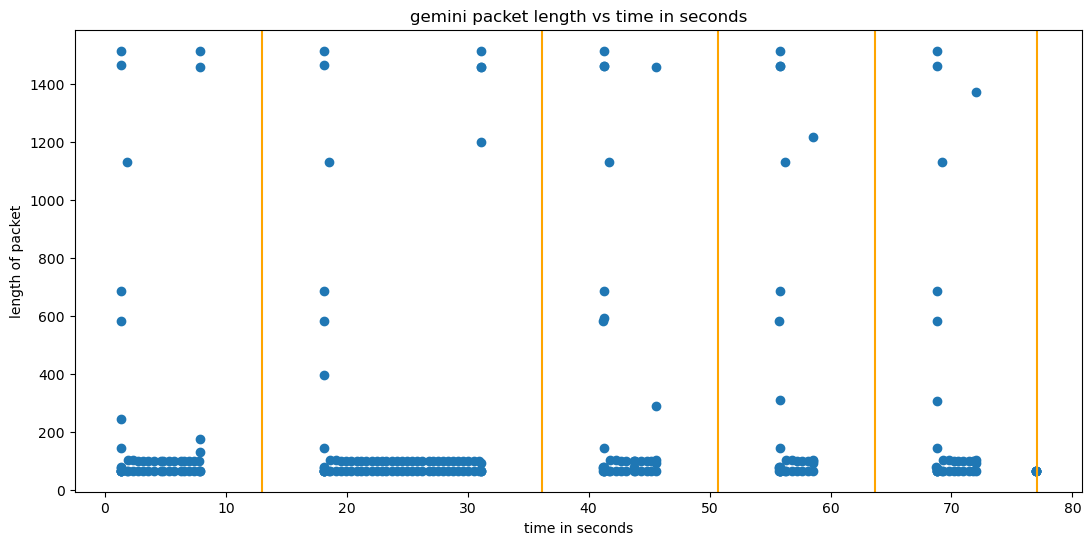

In [127]:
# gemini
plot_first_n_api_calls(gemini_df, 5, "gemini packet length vs time in seconds")

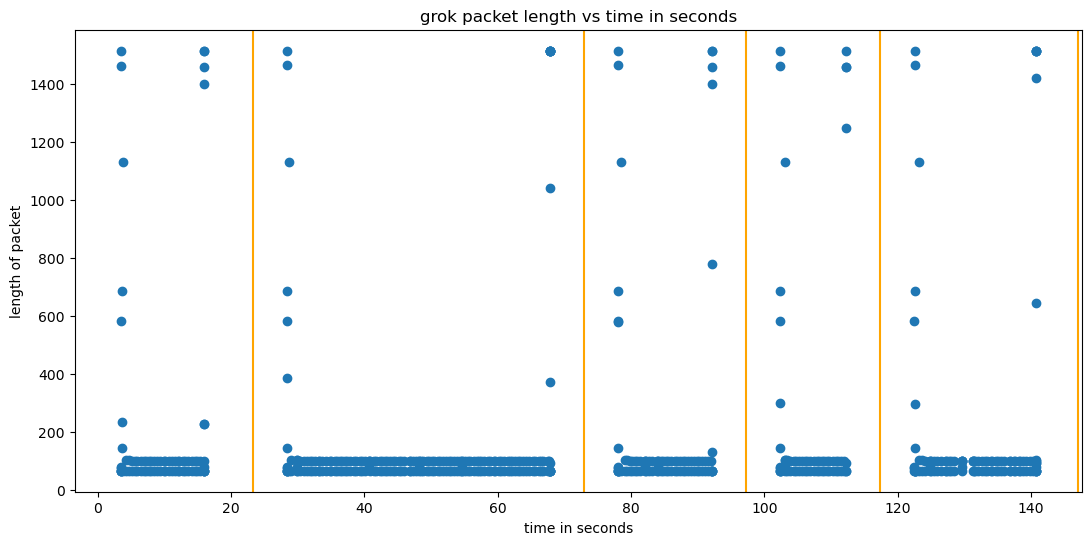

In [128]:
# grok
plot_first_n_api_calls(grok_df, 5, "grok packet length vs time in seconds")

## split data into list of packets for each API call

In [144]:
def split_df_into_api_segments(full_model_df, open_router_ips):
    
    # 2d array where each list corresponds to an api call and the contents of the list are the
    # idxs in the dataframe corresponding to that activity
    idxs = []
    current_segment = []

    for i, row in full_model_df.iterrows():
        info_str = row['Info']
        if ("Standard query response" in info_str) and ('zephaniahdev.com' in info_str):
            idxs.append(current_segment)
            current_segment = []
        else:
            if len(current_segment) == 0:
                if row['Source'] not in open_router_ips and row['Destination'] not in open_router_ips:
                    continue
            current_segment.append(i)

    dfs = []
    for segment in idxs:
        # used claude to know the proper syntax here
        # https://claude.ai/share/28847658-d5bc-4b08-93dd-f71e9240b13f
        dfs.append(full_model_df.iloc[segment].copy())

    non_zero_segmnets = []
    for i, s in enumerate(dfs):
        if len(s) == 0: print("here", i)
        else:
            s_open = s[s['Source'].isin(open_router_ips) | s['Destination'].isin(open_router_ips) ]
            non_zero_segmnets.append(s_open)

    return non_zero_segmnets

In [145]:
open_router_ips = get_open_website_ips(df, "openrouter.ai")
grok_segments = split_df_into_api_segments(grok_df, open_router_ips)
gemini_segments = split_df_into_api_segments(gemini_df, open_router_ips)
llama_segments = split_df_into_api_segments(llama_df, open_router_ips)

here 81


## visualize relationship between bytes and tokens

In [157]:
def plot_tokens_vs_total_bytes(segments, labels, model):
    assert len(segments) == len(labels)

    num_bytes = [sum(s['Length']) for s in segments]
    completion_tokens = [l['completion_tokens'] for l in labels]
    prompt_tokens = [l['prompt_tokens'] for l in labels]

    plt.title(f"{model}: tokens vs bytes in api call flow")
    plt.scatter(num_bytes, completion_tokens, label="completion tokens")
    plt.scatter(num_bytes, prompt_tokens, label="prompt tokens")
    plt.legend()
    plt.show()

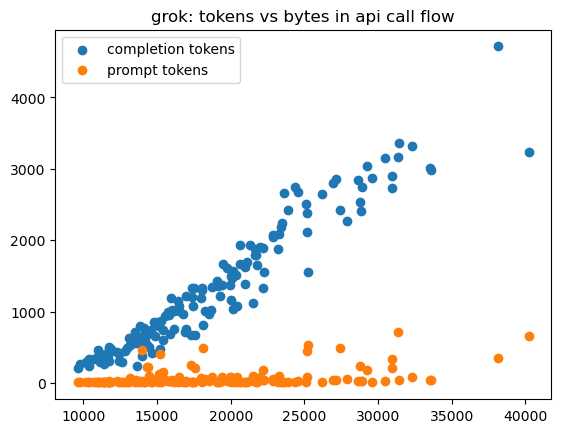

In [158]:
plot_tokens_vs_total_bytes(grok_segments, grok_labels, 'grok')

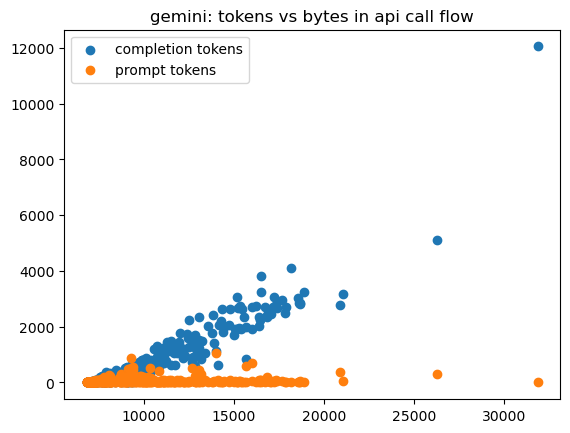

In [160]:
plot_tokens_vs_total_bytes(gemini_segments, gemini_labels, 'gemini')

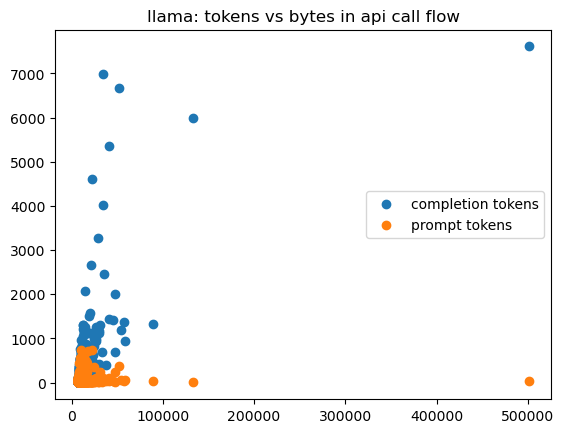

In [161]:
plot_tokens_vs_total_bytes(llama_segments, llama_labels, 'llama')

## motivating issue: where linear models fail 

In [162]:
from sklearn import linear_model

In [195]:
def get_linear_models(segments, labels):
    assert len(segments) == len(labels)

    num_bytes = [sum(s['Length']) for s in segments]
    completion_tokens = [l['completion_tokens'] for l in labels]
    prompt_tokens = [l['prompt_tokens'] for l in labels]

    reg_completion = linear_model.LinearRegression()
    reg_completion.fit(np.array(num_bytes).reshape(-1, 1), completion_tokens)
    m_completion, b_completion = float(reg_completion.coef_[0]), float(reg_completion.intercept_)

    reg_prompt = linear_model.LinearRegression()
    reg_prompt.fit(np.array(num_bytes).reshape(-1, 1), prompt_tokens)
    m_prompt, b_prompt = float(reg_prompt.coef_[0]), float(reg_prompt.intercept_)
    
    return m_completion, b_completion, m_prompt, b_prompt




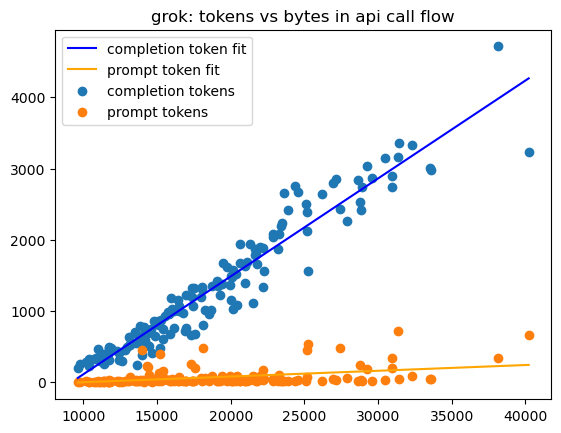

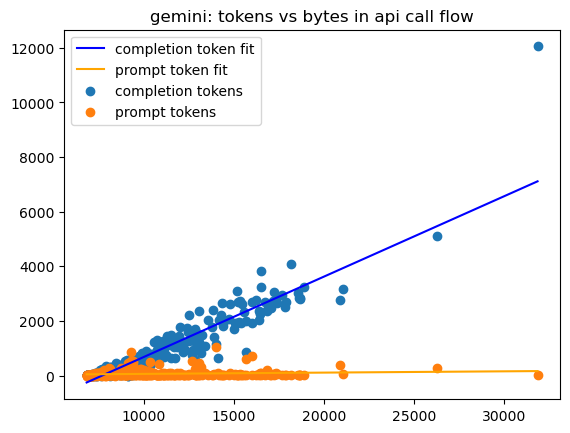

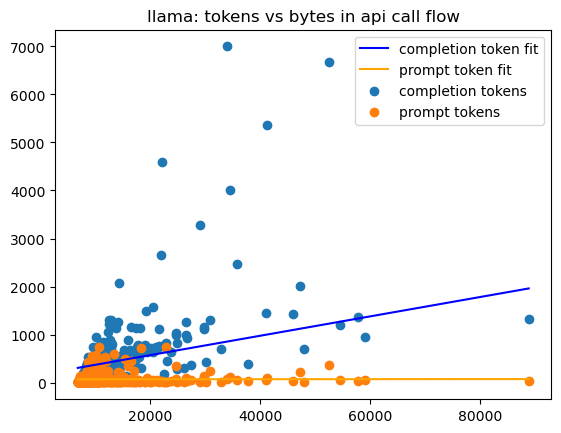

In [217]:
def plot_regression(segments, labels, model, m_completion, b_completion, m_prompt, b_prompt):
    # remove outliers
    segments_new = []
    labels_new = []
    for s,l in zip(segments, labels):
        if not sum(s['Length']) > 100_000:
            segments_new.append(s)
            labels_new.append(l)
    segments, labels = segments_new, labels_new
    
    max_bytes = max([sum(s['Length']) for s in segments])
    min_bytes = min([sum(s['Length']) for s in segments])

    reg_completion_x = np.linspace(min_bytes,max_bytes, max_bytes - min_bytes + 1)
    reg_completion_y = reg_completion_x * m_completion + b_completion

    reg_prompt_x = np.linspace(min_bytes,max_bytes, max_bytes - min_bytes + 1)
    reg_prompt_y = reg_prompt_x * m_prompt + b_prompt
    
    plt.plot(reg_completion_x, reg_completion_y, color='blue', label="completion token fit")
    plt.plot(reg_prompt_x, reg_prompt_y, color='orange', label="prompt token fit")
    
    plot_tokens_vs_total_bytes(segments, labels, model)

m_c, b_c, m_p, b_p = get_linear_models(grok_segments, grok_labels)
plot_regression(grok_segments, grok_labels, 'grok', m_c, b_c, m_p, b_p)

m_c, b_c, m_p, b_p = get_linear_models(gemini_segments, gemini_labels)
plot_regression(gemini_segments, gemini_labels, 'gemini', m_c, b_c, m_p, b_p)

m_c, b_c, m_p, b_p = get_linear_models(llama_segments, llama_labels)
plot_regression(llama_segments, llama_labels, 'llama', m_c, b_c, m_p, b_p)

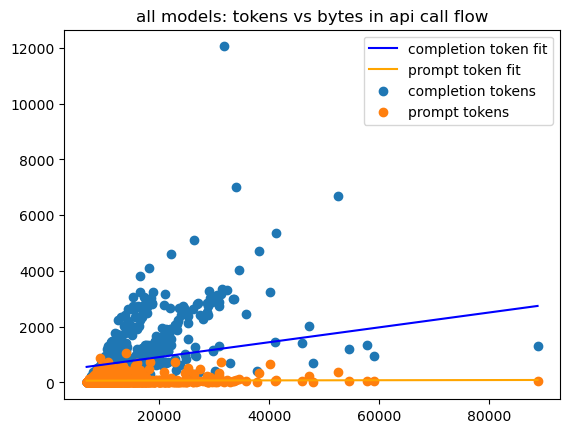

In [218]:
every_api_call = grok_segments + gemini_segments + llama_segments
every_label = grok_labels + gemini_labels + llama_labels

m_c, b_c, m_p, b_p = get_linear_models(every_api_call, every_label)
plot_regression(every_api_call, every_label, 'all models', m_c, b_c, m_p, b_p)

## design data representation for model

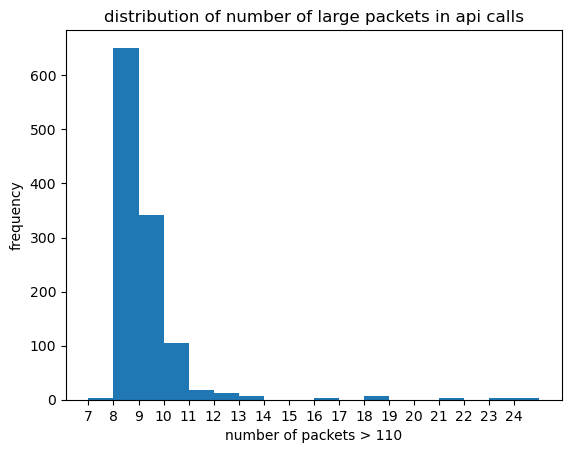

In [90]:
all_segments = [grok_segments, gemini_segments, llama_segments]

def plot_larger_packets_distribution(threshold=110):
    num_larger_packets = []
    
    for api_calls in all_segments:
        for api_call in api_calls:
            num_larger_packets.append(sum(api_call['Length'] >  threshold))

    # I used claude here to make this graph look nicer
    # https://claude.ai/share/af18cc55-c86f-4b1c-8ff1-181511e5e243
    plt.title(f'distribution of number of large packets in api calls')

    min_val = min(num_larger_packets)
    max_val = max(num_larger_packets)
    bins = range(min_val, max_val + 2) 
    
    plt.hist(num_larger_packets, bins=bins)
    plt.xlabel(f'number of packets > {threshold}')
    plt.ylabel('frequency')
    plt.xticks(range(min_val, max_val + 1))

plot_larger_packets_distribution()

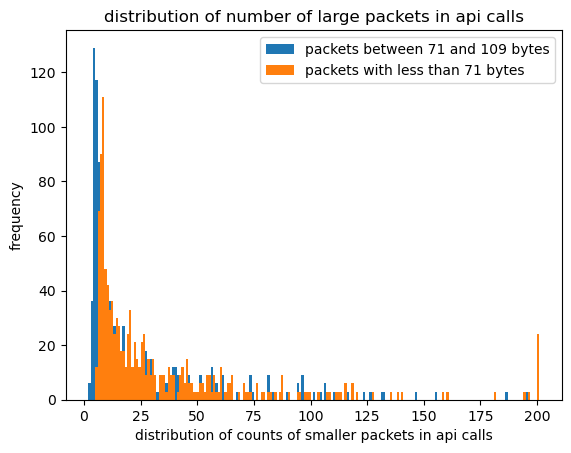

In [222]:
def plot_smaller_packets_distribution():
    small_threshold = 110
    smaller_threshold = 70
    
    num_small_packets = []
    num_smaller_packets = []
    
    
    for api_calls in all_segments:
        for api_call in api_calls:
            num_small = sum((api_call['Length'] <  small_threshold) & (api_call['Length'] >  smaller_threshold))
            num_small_packets.append(min(num_small, 200))
            num_smaller = sum(api_call['Length'] <=  smaller_threshold)
            num_smaller_packets.append(min(num_smaller, 200))

    # I used claude here to make this graph look nicer
    # https://claude.ai/share/af18cc55-c86f-4b1c-8ff1-181511e5e243
    plt.title(f'distribution of number of large packets in api calls')

    min_val = min(min(num_small_packets), min(num_smaller_packets))
    max_val = max(min(num_small_packets), max(num_smaller_packets))
    bins = range(min_val, max_val + 2) 
    
    plt.hist(num_small_packets, bins=bins, label='packets between 71 and 109 bytes')
    plt.hist(num_smaller_packets, bins=bins, label='packets with less than 71 bytes')
    plt.xlabel(f'distribution of counts of smaller packets in api calls')
    plt.ylabel('frequency')
    plt.legend()
    # plt.xscale('log')
    # plt.xticks(range(min_val, max_val + 1))

plot_smaller_packets_distribution()

**My interpretation of the graph above:** In the data we see lots of little packets in between when the api call is made and when the response is received. However, there are very few packets that are larger than 100 bytes even though there may be hundreds of packets assoicated with the api call. 

I believe that there is meaningful signal in the smaller packets, but because they are highly repetitive, I don't think we need to represent them in high resolution.

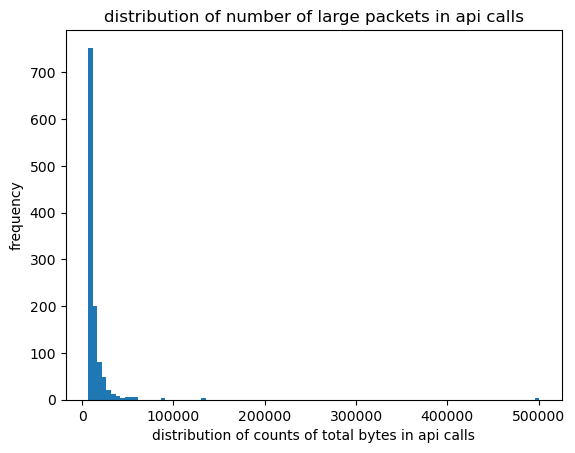

In [219]:
def plot_distribution_total_bytes():
    x = []
    for api_calls in all_segments:
        for api_call in api_calls:
            x.append(sum(api_call['Length']))

    plt.title(f'distribution of number of large packets in api calls')
    
    plt.hist(x,bins=100)
    plt.xlabel(f'distribution of counts of total bytes in api calls')
    plt.ylabel('frequency')
    plt.show()

plot_distribution_total_bytes()

# building the training set

In [108]:
def get_training_set_stats():
    all_times = []
    for api_calls in all_segments:
        for api_call in api_calls:
            times = api_call["Time"] - min(api_call["Time"])
            all_times.extend(list(times))
    print(len(all_times))

    stats = {
        'mean_time': sum(all_times) / len(all_times)
    }
get_training_set_stats()

105738


In [223]:
max(grok_df['Length'])

1514

In [272]:
MAX_NUM_SMALL = 200
MAX_NUM_SMALLER = 200
MAX_PACKET_SIZE = 2_000
MAX_LARGER_BYTES_API_FLOW = 50_000
MAX_LARGER_PACKETS = 20
MAX_TIME = 60

def process_api_df_into_tensor(api_call):
    rv = []

    small_threshold = 110
    smaller_threshold = 70

    # num small packets
    num_small = sum((api_call['Length'] <  small_threshold) & (api_call['Length'] >  smaller_threshold))
    rv.append(float(min(num_small, 200)))

    # num smaller packets
    num_smaller = sum(api_call['Length'] <  smaller_threshold)
    rv.append(float(min(num_smaller, 200)))

    # total_length of larger packets
    total_len_larger = sum(api_call[api_call['Length'] > small_threshold]['Length'])
    rv.append(float(min(total_len_larger, MAX_LARGER_BYTES_API_FLOW)))
    
    # total time
    total_time = api_call.iloc[-1]['Time']  - api_call.iloc[0]['Time']
    # print(total_time)
    rv.append(float(min(total_time, MAX_TIME)))

    larger_packet_data = [0] * (MAX_LARGER_PACKETS * 2 -1)
    min_time = float(min(api_call['Time']))

    idx = 0
    for _, row in api_call.iterrows():
        if idx >= len(larger_packet_data):
            break
        
        if row["Length"] < small_threshold:
            continue
        try:
            
            if row["Length"] == 0:
                print('here', row)

            # time will always be zero for first packet so we don't need to record it
            if idx == 0:
                larger_packet_data[0] = float(min(row["Length"], MAX_PACKET_SIZE))
                idx += 1
            else:
                larger_packet_data[idx] = float(min(row["Length"], MAX_PACKET_SIZE))
                idx += 1
                larger_packet_data[idx] = float(min(row["Time"] - min_time, MAX_TIME))
                idx += 1
        except:
            print(idx)
            assert False
    
    return torch.tensor(rv + larger_packet_data)

    
    
process_api_df_into_tensor(grok_segments[0])

tensor([3.1000e+01, 3.6000e+01, 1.2095e+04, 1.2525e+01, 5.8300e+02, 1.5140e+03,
        1.3569e-01, 1.4630e+03, 1.3878e-01, 1.4600e+02, 1.4567e-01, 6.8500e+02,
        1.4658e-01, 2.3300e+02, 1.4669e-01, 1.1300e+03, 3.6788e-01, 1.4570e+03,
        1.2524e+01, 1.5140e+03, 1.2524e+01, 1.4000e+03, 1.2524e+01, 1.5140e+03,
        1.2525e+01, 2.2800e+02, 1.2525e+01, 2.2800e+02, 1.2525e+01, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00])

In [273]:
grok_data = torch.zeros(len(grok_segments), 43)

for i, s in enumerate(grok_segments):
    grok_data[i] = process_api_df_into_tensor(s)

In [274]:
grok_data.mean(dim=0)

tensor([3.4834e+01, 4.0689e+01, 1.2551e+04, 1.4577e+01, 5.8300e+02, 1.4832e+03,
        9.1902e-01, 1.4656e+03, 9.2946e-01, 2.3326e+02, 9.3502e-01, 6.6666e+02,
        9.3574e-01, 4.0215e+02, 9.3589e-01, 1.0255e+03, 1.4424e+00, 1.3070e+03,
        1.1123e+01, 1.3921e+03, 1.3181e+01, 1.2183e+03, 1.3493e+01, 1.0087e+03,
        1.3121e+01, 7.2652e+02, 1.1455e+01, 4.4528e+02, 8.9638e+00, 3.1044e+02,
        6.3265e+00, 1.6458e+02, 4.1007e+00, 4.5795e+01, 2.0897e+00, 3.0079e+01,
        6.1936e-01, 2.0417e+01, 6.1936e-01, 1.0026e+01, 2.2189e-01, 1.0026e+01,
        2.2189e-01])

In [278]:
grok_data[:, 6]

tensor([0.1357, 0.0451, 0.0769, 0.0743, 0.0932, 0.0881, 0.1008, 0.0655, 0.1332,
        0.1796, 0.0858, 0.1336, 0.1357, 0.0592, 0.0729, 0.1240, 0.0938, 0.1019,
        0.1517, 0.0751, 0.2218, 0.2290, 0.1694, 0.0711, 0.0649, 5.1339, 0.1030,
        0.0667, 0.0631, 0.1963, 0.1054, 5.1283, 0.0737, 0.1050, 4.5600, 0.0748,
        0.0523, 5.1399, 0.2575, 0.0578, 0.0574, 0.2726, 0.0862, 6.1339, 0.0869,
        0.4560, 0.0642, 0.0499, 0.0793, 5.1308, 0.1503, 0.0687, 0.1539, 0.0631,
        0.8683, 5.1139, 0.0750, 0.0648, 0.0845, 0.0817, 0.0487, 5.1649, 0.0940,
        0.0878, 0.0530, 0.1235, 0.2515, 5.1349, 0.2840, 0.0975, 0.0493, 0.0576,
        0.1513, 5.1248, 0.1506, 0.0514, 3.2042, 0.0533, 0.1611, 5.2171, 1.3765,
        0.0793, 0.1462, 0.0475, 0.0602, 5.1287, 0.1946, 0.0664, 0.5264, 0.0598,
        0.1807, 5.1425, 0.0553, 0.0766, 0.1050, 0.1544, 0.0472, 5.1090, 0.0705,
        0.0787, 0.0555, 0.0476, 0.0611, 5.1389, 0.0737, 0.0507, 0.0425, 1.0636,
        0.0553, 5.1475, 0.0643, 0.0878, 

torch.Size([151, 43])


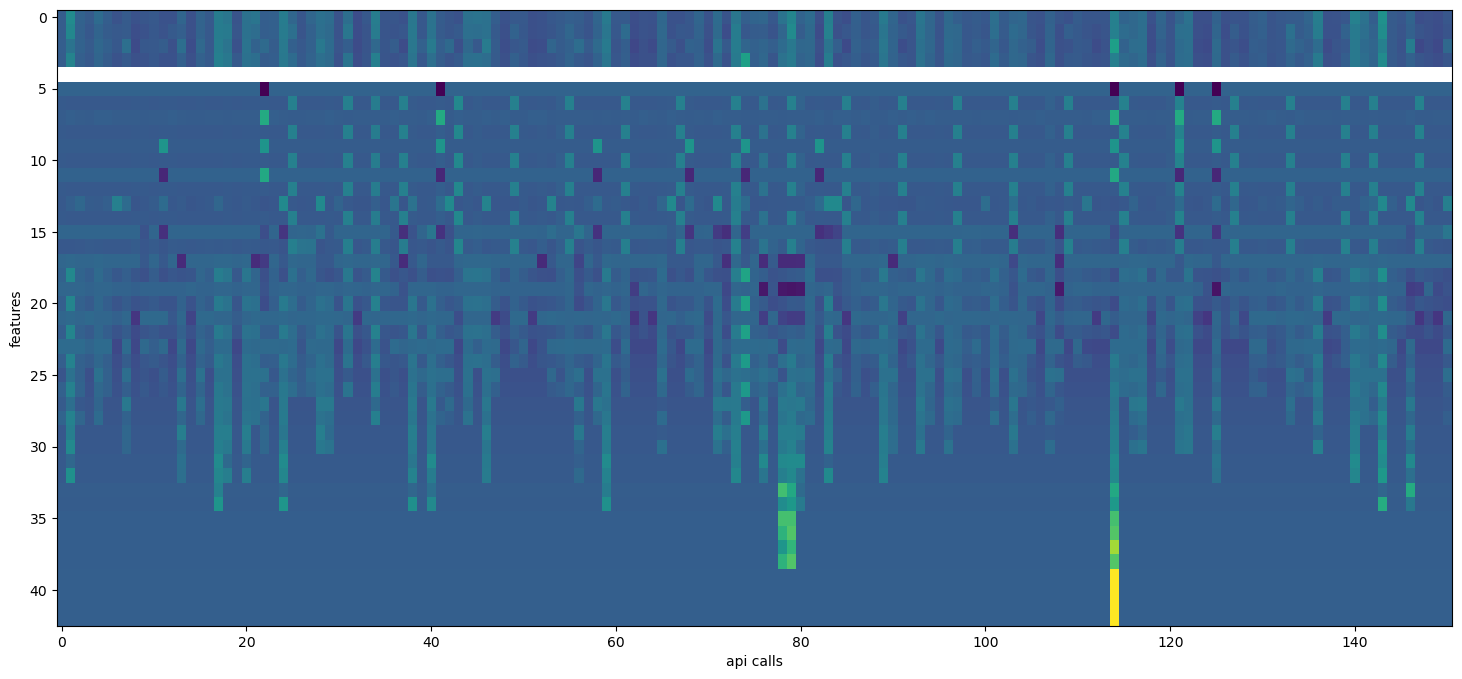

In [276]:

print(grok_data.shape)
grok_normalized = (grok_data - grok_data.mean(dim=0))  / grok_data.std(dim=0)
# plt.imshow(grok_data)
plt.figure(figsize=(18, 8))
plt.imshow(grok_normalized.T, aspect='auto', cmap='viridis')
# plt.colorbar()
plt.ylabel('features')
plt.xlabel('api calls')
plt.show()

In [92]:
grok_segments[0]

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
32,33,3.295909,192.168.111.43,104.18.2.115,TCP,78,55729 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,55729.0,55729.0,33
33,34,3.308987,104.18.2.115,192.168.111.43,TCP,74,"443 > 55729 [SYN, ACK] Seq=0 Ack=1 Win=65535...",55729.0,55729.0,443.0,443.0,34
34,35,3.309147,192.168.111.43,104.18.2.115,TCP,66,55729 > 443 [ACK] Seq=1 Ack=1 Win=131840 Len...,443.0,443.0,55729.0,55729.0,35
35,36,3.309431,192.168.111.43,104.18.2.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,55729.0,55729.0,36
36,37,3.329827,104.18.2.115,192.168.111.43,TCP,66,443 > 55729 [ACK] Seq=1 Ack=518 Win=131072 L...,55729.0,55729.0,443.0,443.0,37
...,...,...,...,...,...,...,...,...,...,...,...,...
122,123,13.727687,192.168.111.43,104.18.2.115,TCP,66,55729 > 443 [ACK] Seq=1400 Ack=4754 Win=1310...,443.0,443.0,55729.0,55729.0,123
124,125,13.851571,104.18.2.115,192.168.111.43,TLSv1.3,1457,Application Data,55729.0,55729.0,443.0,443.0,125
125,126,13.851573,104.18.2.115,192.168.111.43,TLSv1.3,317,Application Data,55729.0,55729.0,443.0,443.0,126
126,127,13.851574,104.18.2.115,192.168.111.43,TLSv1.3,93,Application Data,55729.0,55729.0,443.0,443.0,127


In [67]:
# segments[1]['Length'] < 200

In [58]:
segments[0]

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
32,33,3.295909,192.168.111.43,104.18.2.115,TCP,78,55729 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,55729.0,55729.0,33
33,34,3.308987,104.18.2.115,192.168.111.43,TCP,74,"443 > 55729 [SYN, ACK] Seq=0 Ack=1 Win=65535...",55729.0,55729.0,443.0,443.0,34
34,35,3.309147,192.168.111.43,104.18.2.115,TCP,66,55729 > 443 [ACK] Seq=1 Ack=1 Win=131840 Len...,443.0,443.0,55729.0,55729.0,35
35,36,3.309431,192.168.111.43,104.18.2.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,55729.0,55729.0,36
36,37,3.329827,104.18.2.115,192.168.111.43,TCP,66,443 > 55729 [ACK] Seq=1 Ack=518 Win=131072 L...,55729.0,55729.0,443.0,443.0,37
...,...,...,...,...,...,...,...,...,...,...,...,...
122,123,13.727687,192.168.111.43,104.18.2.115,TCP,66,55729 > 443 [ACK] Seq=1400 Ack=4754 Win=1310...,443.0,443.0,55729.0,55729.0,123
124,125,13.851571,104.18.2.115,192.168.111.43,TLSv1.3,1457,Application Data,55729.0,55729.0,443.0,443.0,125
125,126,13.851573,104.18.2.115,192.168.111.43,TLSv1.3,317,Application Data,55729.0,55729.0,443.0,443.0,126
126,127,13.851574,104.18.2.115,192.168.111.43,TLSv1.3,93,Application Data,55729.0,55729.0,443.0,443.0,127


In [22]:
ts = [l['completion_tokens'] for l in labels]
ts2 = [l['prompt_tokens'] for l in labels]
lens = [sum(segment['Length']) for segment in non_zero_segmnets]

In [23]:
len(lens), len(ts)

(385, 385)

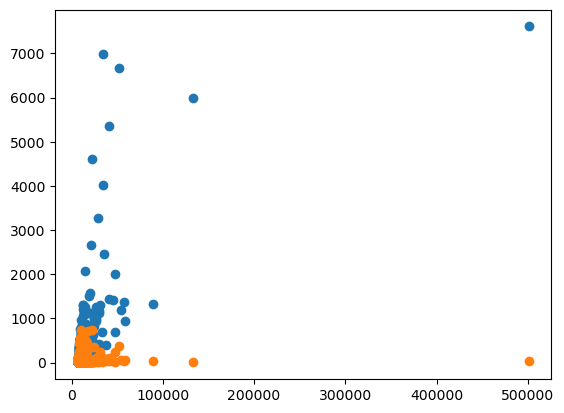

In [24]:
plt.scatter(lens, ts)
plt.scatter(lens, ts2)

In [ ]:
def segment_to_array():
    # if [SYN] in info, bit is on, otherwise off
    # if [ACC] in info, bit is on, otherwise off
    # if non-handshake tcp packet, bit is on, otherwise off
    # len of packet / 1000
    # time from first packet in api call / 10

In [61]:
max(lens)

23586381

In [37]:
df = pd.read_csv("pcaps/first_full_run.csv", encoding='latin-1')

open_router_ips = get_open_website_ips(df, "openrouter.ai")
# zephaniah_dev_ips = get_open_website_ips(df, "zephaniahdev.com")

In [38]:
open_router_ips

['104.18.2.115', '104.18.3.115']

In [45]:
only_open_router = df[df['Source'].isin(open_router_ips) | df['Destination'].isin(open_router_ips) ]

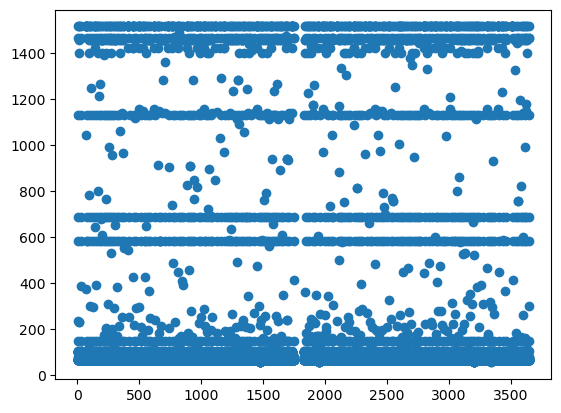

In [46]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'])
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
# plt.legend()
plt.show()

In [39]:
# segments = split_df_into_api_segments(df, open_router_ips)

In [40]:
only_open_router = segments[2][segments[2]['Source'].isin(open_router_ips) | segments[2]['Destination'].isin(open_router_ips) ]

In [41]:
len(segments)

152

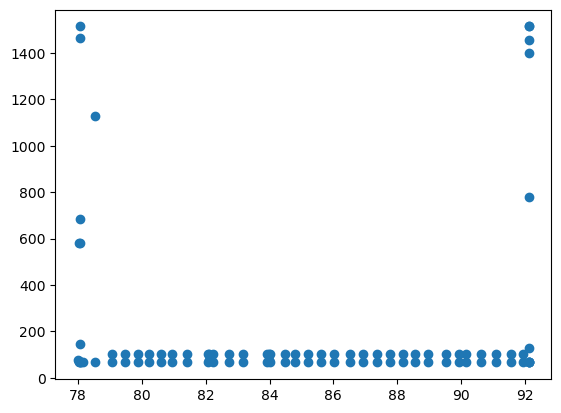

In [44]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'])
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
# plt.legend()
plt.show()

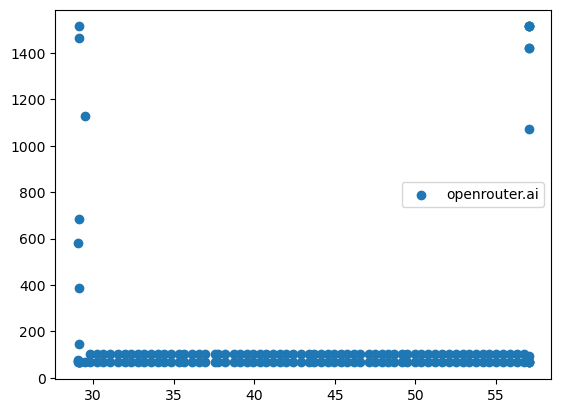

In [316]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

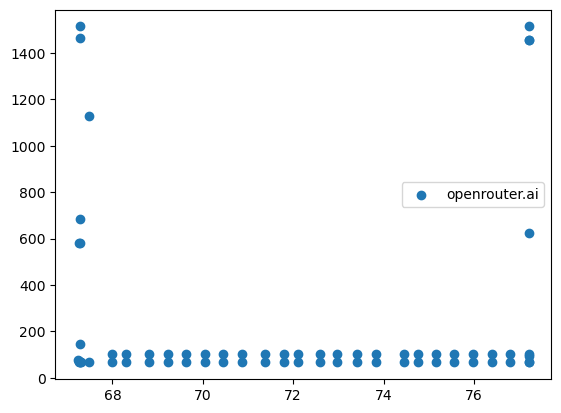

In [323]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

In [256]:
np.array(get_website_mask(df, open_router_ips))

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [253]:
import matplotlib.pyplot as plt
full = pd.read_csv("pcaps/test1.csv", encoding='latin-1')
open_router_ips = get_open_website_ips(df, "openrouter.ai")

only_open_router = full[get_website_mask(full, open_router_ips)]
# only_zephaniah_dev = df[get_website_mask(df, zephaniah_dev_ips)]

# plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
# # plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
# plt.legend()
# plt.show()

In [254]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,3.404999,192.168.111.43,104.18.3.115,TCP,78,60505 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,60505.0,60505.0,23
23,24,3.429753,104.18.3.115,192.168.111.43,TCP,74,"443 > 60505 [SYN, ACK] Seq=0 Ack=1 Win=65535...",60505.0,60505.0,443.0,443.0,24
24,25,3.429859,192.168.111.43,104.18.3.115,TCP,66,60505 > 443 [ACK] Seq=1 Ack=1 Win=131840 Len...,443.0,443.0,60505.0,60505.0,25
25,26,3.430176,192.168.111.43,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,60505.0,60505.0,26
26,27,3.460792,104.18.3.115,192.168.111.43,TCP,66,443 > 60505 [ACK] Seq=1 Ack=518 Win=131072 L...,60505.0,60505.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,7.673535,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.102? Tell 192.168.111.75,NaN,NaN,NaN,NaN,154
154,155,7.718554,17.171.47.23,192.168.111.43,TCP,60,443 > 60487 [RST] Seq=33 Win=0 Len=0,60487.0,60487.0,443.0,443.0,155
209,210,9.308719,192.168.111.43,17.171.47.23,TCP,66,60496 > 443 [ACK] Seq=1 Ack=33 Win=88 Len=0 ...,443.0,443.0,60496.0,60496.0,210
213,214,9.360930,17.171.47.23,192.168.111.43,TCP,60,443 > 60496 [RST] Seq=33 Win=0 Len=0,60496.0,60496.0,443.0,443.0,214


In [182]:
df

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
0,1,0.000000,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.149? Tell 192.168.111.75,NaN,NaN,NaN,NaN,1
1,2,0.205246,ASUSTekCOMPU_1f:de:80,Apple_1c:fe:8a,ARP,60,Who has 192.168.111.43? Tell 192.168.111.1,NaN,NaN,NaN,NaN,2
2,3,0.205367,Apple_1c:fe:8a,ASUSTekCOMPU_1f:de:80,ARP,42,192.168.111.43 is at 3c:a6:f6:1c:fe:8a,NaN,NaN,NaN,NaN,3
3,4,0.301654,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.161? Tell 192.168.111.75,NaN,NaN,NaN,NaN,4
4,5,0.925164,192.168.111.45,224.0.0.251,MDNS,100,Standard query 0x0000 PTR _companion-link._tcp...,5353.0,5353.0,5353.0,5353.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
827,828,90.314933,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.220? Tell 192.168.111.75,NaN,NaN,NaN,NaN,828
828,829,90.625592,192.168.111.153,224.0.0.251,MDNS,120,Standard query 0x0000 SRV HP Color LaserJet Pr...,5353.0,5353.0,5353.0,5353.0,829
829,830,90.931959,192.168.111.17,224.0.0.251,MDNS,204,Standard query 0x0000 PTR _companion-link._tcp...,5353.0,5353.0,5353.0,5353.0,830
830,831,91.244801,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.136? Tell 192.168.111.75,NaN,NaN,NaN,NaN,831


In [181]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,3.404999,192.168.111.43,104.18.3.115,TCP,78,60505 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,60505.0,60505.0,23
23,24,3.429753,104.18.3.115,192.168.111.43,TCP,74,"443 > 60505 [SYN, ACK] Seq=0 Ack=1 Win=65535...",60505.0,60505.0,443.0,443.0,24
24,25,3.429859,192.168.111.43,104.18.3.115,TCP,66,60505 > 443 [ACK] Seq=1 Ack=1 Win=131840 Len...,443.0,443.0,60505.0,60505.0,25
25,26,3.430176,192.168.111.43,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,60505.0,60505.0,26
26,27,3.460792,104.18.3.115,192.168.111.43,TCP,66,443 > 60505 [ACK] Seq=1 Ack=518 Win=131072 L...,60505.0,60505.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,7.673535,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.102? Tell 192.168.111.75,NaN,NaN,NaN,NaN,154
154,155,7.718554,17.171.47.23,192.168.111.43,TCP,60,443 > 60487 [RST] Seq=33 Win=0 Len=0,60487.0,60487.0,443.0,443.0,155
209,210,9.308719,192.168.111.43,17.171.47.23,TCP,66,60496 > 443 [ACK] Seq=1 Ack=33 Win=88 Len=0 ...,443.0,443.0,60496.0,60496.0,210
213,214,9.360930,17.171.47.23,192.168.111.43,TCP,60,443 > 60496 [RST] Seq=33 Win=0 Len=0,60496.0,60496.0,443.0,443.0,214


In [96]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,15.196938,10.150.14.95,104.18.3.115,TCP,78,57361 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,57361.0,57361.0,23
23,24,15.208490,104.18.3.115,10.150.14.95,TCP,74,"443 > 57361 [SYN, ACK] Seq=0 Ack=1 Win=65535...",57361.0,57361.0,443.0,443.0,24
24,25,15.208649,10.150.14.95,104.18.3.115,TCP,66,57361 > 443 [ACK] Seq=1 Ack=1 Win=131520 Len...,443.0,443.0,57361.0,57361.0,25
25,26,15.209370,10.150.14.95,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,57361.0,57361.0,26
26,27,15.252591,104.18.3.115,10.150.14.95,TCP,66,443 > 57361 [ACK] Seq=1 Ack=518 Win=131072 L...,57361.0,57361.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,31.361033,104.18.3.115,10.150.14.95,TLSv1.3,1064,"Application Data, Application Data, Applicatio...",57361.0,57361.0,443.0,443.0,154
154,155,31.361375,10.150.14.95,104.18.3.115,TCP,66,57361 > 443 [ACK] Seq=1336 Ack=10382 Win=131...,443.0,443.0,57361.0,57361.0,155
209,210,54.055280,10.150.14.95,104.18.3.115,TCP,66,"57361 > 443 [FIN, ACK] Seq=1336 Ack=10382 Wi...",443.0,443.0,57361.0,57361.0,210
213,214,54.229522,104.18.3.115,10.150.14.95,TCP,66,"443 > 57361 [FIN, ACK] Seq=10382 Ack=1337 Wi...",57361.0,57361.0,443.0,443.0,214


In [97]:
only_zephaniah_dev

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
164,165,43.620507,10.150.14.95,46.202.197.140,TCP,78,57363 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,57363.0,57363.0,165
166,167,43.741637,46.202.197.140,10.150.14.95,TCP,74,"443 > 57363 [SYN, ACK] Seq=0 Ack=1 Win=31856...",57363.0,57363.0,443.0,443.0,167
167,168,43.741828,10.150.14.95,46.202.197.140,TCP,66,57363 > 443 [ACK] Seq=1 Ack=1 Win=131520 Len...,443.0,443.0,57363.0,57363.0,168
168,169,43.777993,10.150.14.95,46.202.197.140,TLSv1.3,583,Client Hello (SNI=zephaniahdev.com),443.0,443.0,57363.0,57363.0,169
169,170,43.896586,46.202.197.140,10.150.14.95,TCP,66,443 > 57363 [ACK] Seq=1 Ack=518 Win=31872 Le...,57363.0,57363.0,443.0,443.0,170
170,171,43.902648,46.202.197.140,10.150.14.95,TLSv1.3,1436,"Server Hello, Change Cipher Spec",57363.0,57363.0,443.0,443.0,171
171,172,43.902651,46.202.197.140,10.150.14.95,TCP,941,[TCP Previous segment not captured] 443 > 57...,57363.0,57363.0,443.0,443.0,172
172,173,43.902652,46.202.197.140,10.150.14.95,TLSv1.3,1436,"[TCP Retransmission] , Application Data",57363.0,57363.0,443.0,443.0,173
173,174,43.902749,10.150.14.95,46.202.197.140,TCP,66,57363 > 443 [ACK] Seq=518 Ack=1371 Win=13011...,443.0,443.0,57363.0,57363.0,174
174,175,43.902819,10.150.14.95,46.202.197.140,TCP,78,[TCP Dup ACK 174#1] 57363 > 443 [ACK] Seq=51...,443.0,443.0,57363.0,57363.0,175


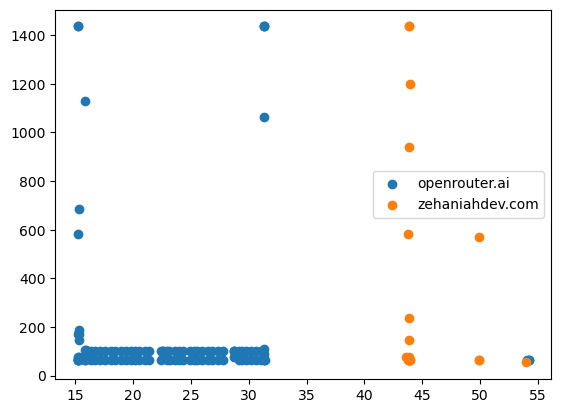

In [98]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

In [55]:
df['Source']

0        10.150.14.95
1        10.150.14.95
2        10.150.14.95
3        10.150.14.95
4       17.57.144.135
            ...      
232    17.248.168.168
233    17.248.168.168
234        10.150.0.2
235        10.150.0.2
236      10.150.14.95
Name: Source, Length: 237, dtype: object

In [51]:
(df['Source'] == '104.18.2.115') | (df['Destination'] == '104.18.2.115')

0      False
1      False
2      False
3      False
4      False
       ...  
232    False
233    False
234    False
235    False
236    False
Length: 237, dtype: bool